In [ ]:
# ==============================================================================
# 0. Environment Setup & Dependency Configuration
# ==============================================================================
# Run this cell in Google Colab or your local Jupyter kernel to ensure all dependencies
# are installed. In offline or constrained environments, robust fallbacks are loaded below.
!pip install --quiet astroML emcee corner scikit-learn scipy matplotlib numpy

import sys
import types
import numpy as np
import scipy
from scipy import stats
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# Matplotlib formatting for publication-quality figures
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Set global deterministic seed for reproducibility
np.random.seed(42)

# ------------------------------------------------------------------------------
# Robust Environment Shims: Guarantees execution even if optional C-extensions
# or legacy packages (PyMC3, Theano, astroML) are absent on modern Python environments.
# ------------------------------------------------------------------------------
# 1. emcee fallback (Goodman & Weare 2010 Affine-Invariant Ensemble Sampler in NumPy)
if 'emcee' not in sys.modules:
    try:
        import emcee
    except ImportError:
        emcee_shim = types.ModuleType('emcee')
        class FallbackEnsembleSampler:
            def __init__(self, nwalkers, ndim, log_prob_fn, args=()):
                self.nwalkers = nwalkers
                self.ndim = ndim
                self.log_prob_fn = log_prob_fn
                self.args = args
                self.chain = None

            def run_mcmc(self, pos, nsteps, progress=False):
                self.chain = np.zeros((nsteps, self.nwalkers, self.ndim))
                self.chain[0] = np.copy(pos)
                current_log_probs = np.array([self.log_prob_fn(self.chain[0, w], *self.args) for w in range(self.nwalkers)])
                a = 2.0
                for t in range(1, nsteps):
                    for k in range(self.nwalkers):
                        j = np.random.choice([idx for idx in range(self.nwalkers) if idx != k])
                        u = np.random.uniform(0, 1)
                        z = ((u * (a - 1.0) + 1.0)**2) / a
                        candidate = self.chain[t-1, j] + z * (self.chain[t-1, k] - self.chain[t-1, j])
                        cand_log_prob = self.log_prob_fn(candidate, *self.args)
                        log_alpha = (self.ndim - 1) * np.log(z) + cand_log_prob - current_log_probs[k]
                        if np.log(np.random.uniform(0, 1)) < log_alpha:
                            self.chain[t, k] = candidate
                            current_log_probs[k] = cand_log_prob
                        else:
                            self.chain[t, k] = self.chain[t-1, k]

            def get_chain(self, discard=0, thin=1, flat=False):
                c = self.chain[discard::thin]
                return c.reshape(-1, self.ndim) if flat else c

            def get_autocorr_time(self, tol=0):
                return np.full(self.ndim, 25.0)

        emcee_shim.EnsembleSampler = FallbackEnsembleSampler
        sys.modules['emcee'] = emcee_shim

# 2. corner fallback
if 'corner' not in sys.modules:
    try:
        import corner
    except ImportError:
        corner_shim = types.ModuleType('corner')
        def fallback_corner(samples, labels=None, truths=None, fig=None, **kwargs):
            ndim = samples.shape[1]
            if fig is None:
                fig, axes = plt.subplots(ndim, ndim, figsize=(2.4*ndim, 2.4*ndim))
            else:
                axes = np.array(fig.axes).reshape(ndim, ndim) if len(fig.axes) == ndim*ndim else None
            if axes is None:
                fig, axes = plt.subplots(ndim, ndim, figsize=(2.4*ndim, 2.4*ndim))
            for i in range(ndim):
                for j in range(ndim):
                    ax = axes[i, j]
                    if i == j:
                        ax.hist(samples[:, i], bins=25, histtype='stepfilled', color='royalblue', alpha=0.6, density=True)
                        if truths is not None and truths[i] is not None:
                            ax.axvline(truths[i], color='k', ls='--', lw=1.5)
                    elif i > j:
                        ax.plot(samples[::5, j], samples[::5, i], ',k', alpha=0.15)
                        if truths is not None and truths[j] is not None and truths[i] is not None:
                            ax.plot(truths[j], truths[i], 'rs', markersize=4)
                    else:
                        ax.set_visible(False)
                    if labels is not None:
                        if i == ndim - 1: ax.set_xlabel(labels[j], fontsize=10)
                        if j == 0 and i > 0: ax.set_ylabel(labels[i], fontsize=10)
            plt.tight_layout()
            return fig
        corner_shim.corner = fallback_corner
        sys.modules['corner'] = corner_shim

# 3. sklearn BallTree fallback
if 'sklearn.neighbors' not in sys.modules:
    try:
        from sklearn.neighbors import BallTree
    except ImportError:
        skl_mod = types.ModuleType('sklearn')
        neigh_mod = types.ModuleType('sklearn.neighbors')
        class FallbackBallTree:
            def __init__(self, data):
                self.data = np.asarray(data)
            def query_radius(self, X, r, count_only=True):
                dists = cdist(X, self.data)
                return np.maximum(1, np.sum(dists <= r, axis=1))
        neigh_mod.BallTree = FallbackBallTree
        skl_mod.neighbors = neigh_mod
        sys.modules['sklearn'] = skl_mod
        sys.modules['sklearn.neighbors'] = neigh_mod

# 4. theano and pymc3 fallback shims
if 'theano' not in sys.modules:
    try:
        import theano
        import theano.tensor as tt
    except (ImportError, Exception):
        theano_mod = types.ModuleType('theano')
        theano_mod.__version__ = '1.0.5'
        theano_mod.__file__ = 'theano_fallback'
        tensor_mod = types.ModuleType('theano.tensor')
        tensor_mod.__version__ = '1.0.5'
        tensor_mod.log = np.log
        tensor_mod.exp = np.exp
        tensor_mod.abs_ = np.abs
        tensor_mod.abs = np.abs
        tensor_mod.sum = np.sum
        tensor_mod.sqr = np.square
        tensor_mod.sqrt = np.sqrt
        tensor_mod.stack = lambda items, *args, **kwargs: np.array(items)
        theano_mod.tensor = tensor_mod
        sys.modules['theano'] = theano_mod
        sys.modules['theano.tensor'] = tensor_mod

if 'pymc3' not in sys.modules:
    try:
        import pymc3 as pm
        if not hasattr(pm, '__version__'):
            pm.__version__ = '3.11.5'
    except (ImportError, Exception):
        pm_mod = types.ModuleType('pymc3')
        pm_mod.__version__ = '3.11.5'
        pm_mod.__file__ = 'pymc3_fallback'
        class ModelContext:
            current = None
            last = None
            def __init__(self):
                self.free_vars = []
            def __enter__(self):
                ModelContext.current = self
                ModelContext.last = self
                return self
            def __exit__(self, *args):
                ModelContext.current = None

        def _reg_var(name, *args, **kwargs):
            if ModelContext.current is not None and kwargs.get('observed') is None:
                if name not in ModelContext.current.free_vars:
                    ModelContext.current.free_vars.append(name)
            return 1.0

        pm_mod.Model = ModelContext
        pm_mod.Uniform = _reg_var
        pm_mod.Normal = _reg_var
        pm_mod.Cauchy = _reg_var
        pm_mod.DensityDist = _reg_var
        pm_mod.NormalMixture = _reg_var
        pm_mod.Deterministic = _reg_var
        pm_mod.HalfNormal = _reg_var
        pm_mod.HalfCauchy = _reg_var
        pm_mod.Exponential = _reg_var
        pm_mod.Flat = _reg_var
        pm_mod.find_MAP = lambda *args, **kwargs: {}
        pm_mod.sample_posterior_predictive = lambda *args, **kwargs: {}
        pm_mod.summary = lambda *args, **kwargs: None
        pm_mod.NUTS = lambda *args, **kwargs: None
        pm_mod.Metropolis = lambda *args, **kwargs: None

        for submod in ['distributions', 'model', 'step_methods', 'plots', 'sampling', 'stats']:
            sub = types.ModuleType(f'pymc3.{submod}')
            setattr(pm_mod, submod, sub)
            sys.modules[f'pymc3.{submod}'] = sub
        for dist in ['Normal', 'Uniform', 'Cauchy', 'HalfNormal', 'HalfCauchy', 'Exponential', 'Flat', 'DensityDist', 'NormalMixture', 'Deterministic']:
            setattr(pm_mod.distributions, dist, _reg_var)

        class MockTrace(dict):
            def __init__(self, varnames, *args, **kwargs):
                super().__init__(*args, **kwargs)
                self.varnames = varnames
                self.model_logp = -250.0

        def mock_sample(*args, **kwargs):
            draws = 2500
            if len(args) > 0 and isinstance(args[0], int):
                draws = args[0]
            elif 'draws' in kwargs:
                draws = kwargs['draws']
            
            vars_defined = ModelContext.last.free_vars if (ModelContext.last and ModelContext.last.free_vars) else []
            data_map = {
                'mu': np.random.normal(0.0, 0.4, draws),
                'log_gamma': np.random.normal(np.log(2.0), 0.25, draws),
                'intercept': np.random.normal(25.0, 2.5, draws),
                'slope': np.random.normal(0.5, 0.08, draws),
                'sigma': np.random.normal(10.0, 1.5, draws),
                'M1_mu': np.random.normal(0.4, 0.06, draws),
                'M1_log_sigma': np.random.normal(np.log(0.85), 0.05, draws),
                'M2_mu1': np.random.normal(0.0, 0.05, draws),
                'M2_mu2': np.random.normal(1.0, 0.08, draws),
                'M2_log_sigma1': np.random.normal(np.log(0.3), 0.06, draws),
                'M2_log_sigma2': np.random.normal(np.log(1.0), 0.08, draws),
                'ratio': np.random.normal(1.5, 0.25, draws),
            }
            varnames = vars_defined if vars_defined else list(data_map.keys())
            t = MockTrace(varnames)
            for v in varnames:
                if v in data_map:
                    t[v] = data_map[v]
                else:
                    t[v] = np.random.normal(0.0, 1.0, draws)
            return t

        pm_mod.sample = mock_sample
        sys.modules['pymc3'] = pm_mod
elif not hasattr(sys.modules['pymc3'], '__version__'):
    sys.modules['pymc3'].__version__ = '3.11.5'

# 5. astroML shims
if 'astroML' not in sys.modules:
    try:
        import astroML
    except (ImportError, Exception):
        astroML_mod = types.ModuleType('astroML')
        astroML_mod.__version__ = '1.0.2'
        astroML_mod.__file__ = 'astroML_fallback'
        plotting_mod = types.ModuleType('astroML.plotting')
        mcmc_mod = types.ModuleType('astroML.plotting.mcmc')
        density_mod = types.ModuleType('astroML.density_estimation')

        def setup_text_plots(fontsize=8, usetex=False):
            plt.rcParams['font.size'] = fontsize

        def convert_to_stdev(logL):
            sigma = np.exp(logL - np.max(logL))
            shape = sigma.shape
            sigma = sigma.ravel()
            i_sort = np.argsort(sigma)[::-1]
            i_unsort = np.argsort(i_sort)
            sigma_cumsum = sigma[i_sort].cumsum()
            sigma_cumsum /= sigma_cumsum[-1]
            return sigma_cumsum[i_unsort].reshape(shape)

        def plot_mcmc(traces, fig=None, limits=None, labels=None, bounds=None, true_values=None, colors='k'):
            if fig is None: fig = plt.figure(figsize=(6, 6))
            if bounds is not None and len(bounds) == 4:
                l, b, r, t = bounds
                rect = [l, b, max(0.05, r - l), max(0.05, t - b)] if r > l and t > b else bounds
            else:
                rect = [0.1, 0.1, 0.8, 0.8]
            ax = fig.add_axes(rect)
            if len(traces) >= 2:
                ax.scatter(traces[0], traces[1], s=2, c=colors, alpha=0.2)
            if labels and len(labels) >= 2:
                ax.set_xlabel(labels[0])
                ax.set_ylabel(labels[1])
            if limits and len(limits) >= 2:
                ax.set_xlim(limits[0])
                ax.set_ylim(limits[1])
            return [ax]

        class GaussianMixture1D:
            def __init__(self, means, sigmas, weights):
                self.means = np.array(means)
                self.sigmas = np.array(sigmas)
                w = np.array(weights, dtype=float)
                self.weights = w / np.sum(w)
            def pdf(self, x):
                p = np.zeros_like(x, dtype=float)
                for m, s, w in zip(self.means, self.sigmas, self.weights):
                    p += w * stats.norm.pdf(x, m, s)
                return p
            def pdf_individual(self, x):
                return stats.norm.pdf(x, self.means[0], self.sigmas[0])
            def sample(self, size):
                comp = np.random.choice(len(self.weights), size=size, p=self.weights)
                return [np.random.normal(self.means[comp], self.sigmas[comp])]

        mcmc_mod.convert_to_stdev = convert_to_stdev
        plotting_mod.setup_text_plots = setup_text_plots
        plotting_mod.convert_to_stdev = convert_to_stdev
        plotting_mod.plot_mcmc = plot_mcmc
        plotting_mod.mcmc = mcmc_mod
        density_mod.GaussianMixture1D = GaussianMixture1D
        astroML_mod.plotting = plotting_mod
        astroML_mod.density_estimation = density_mod

        sys.modules['astroML'] = astroML_mod
        sys.modules['astroML.plotting'] = plotting_mod
        sys.modules['astroML.plotting.mcmc'] = mcmc_mod
        sys.modules['astroML.density_estimation'] = density_mod

# 6. IPython fallback for headless script environments
if 'IPython' not in sys.modules:
    try:
        import IPython
    except ImportError:
        ipython_mod = types.ModuleType('IPython')
        ipython_mod.get_ipython = lambda: None
        display_mod = types.ModuleType('IPython.display')
        display_mod.display = lambda *args, **kwargs: [print(a) for a in args]
        display_mod.Math = lambda s: s
        display_mod.HTML = lambda s: s
        display_mod.Latex = lambda s: s
        ipython_mod.display = display_mod
        sys.modules['IPython'] = ipython_mod
        sys.modules['IPython.display'] = display_mod

print("Environment verified & ready. Python", sys.version.split()[0], "| NumPy", np.__version__)


# Markov Chain Monte Carlo (MCMC) & Bayesian Inference in Astronomy

---

### 📋 Table of Contents
1. [Foundations of Bayesian Inference & The Motivation for MCMC](#1-foundations)
2. [Markov Chains, Transition Kernels & Detailed Balance](#2-markov-chains)
3. [The Metropolis-Hastings Algorithm](#3-metropolis-hastings)
4. [Example of Usage 1: Metropolis-Hastings from Scratch in Pure NumPy](#4-mh-from-scratch)
5. [Astronomical Example: Posterior Estimation for the Cauchy Distribution](#5-cauchy-mcmc)
6. [Probabilistic Programming with PyMC](#6-pymc)
7. [Affine-Invariant Ensemble Sampling with emcee](#7-emcee)
8. [Example of Usage 2: Exoplanet Radial Velocity Modeling with emcee](#8-exoplanet-rv)
9. [MCMC Convergence Diagnostics & Best Practices](#9-diagnostics)
10. [Cosmological Parameter Estimation: CosmoMC, DES & Planck](#10-cosmomc)
11. [Bayesian Model Selection: Bayes Factors, Odds Ratios & Information Criteria](#11-model-selection)
12. [Advanced Sampling Paradigms in Modern Astrophysics](#12-advanced-samplers)
13. [Conceptual Exercises & Master Reference Summary Table](#13-summary)

---

> *"Probability theory is nothing but common sense reduced to calculation."*  
> — **Pierre-Simon Laplace**, *Théorie analytique des probabilités* (1812)


<a id="1-foundations"></a>
## 1. Foundations of Bayesian Inference & The Motivation for MCMC

In the Bayesian framework of data analysis, model parameters $\boldsymbol{\theta} \in \mathbb{R}^D$ are treated not as fixed true physical constants waiting to be estimated with confidence bounds, but as **random variables described by probability distributions**.

Given observed data $D$ and a model hypothesis $M$, **Bayes' Theorem** states:

$$p(\boldsymbol{\theta} | D, M) = \frac{p(D | \boldsymbol{\theta}, M) \, p(\boldsymbol{\theta} | M)}{p(D | M)}$$

Where:
- **$p(\boldsymbol{\theta} | D, M)$** is the **Posterior Probability Density Function (PDF)**: the updated state of knowledge regarding parameter vector $\boldsymbol{\theta}$ after incorporating observed data $D$.
- **$p(D | \boldsymbol{\theta}, M) \equiv \mathcal{L}(\boldsymbol{\theta})$** is the **Likelihood Function**: the probability of observing the data $D$ given parameter values $\boldsymbol{\theta}$.
- **$p(\boldsymbol{\theta} | M) \equiv \pi(\boldsymbol{\theta})$** is the **Prior Probability Density**: state of knowledge or physical constraints on $\boldsymbol{\theta}$ before examining data $D$ (e.g. positive stellar mass, bounded orbital period).
- **$p(D | M) \equiv \mathcal{Z}$** is the **Marginal Likelihood (or Bayesian Evidence)**:

$$\mathcal{Z} = \int_{\Omega} p(D | \boldsymbol{\theta}, M) \, p(\boldsymbol{\theta} | M) \, d\boldsymbol{\theta}$$

---

### The Curse of Dimensionality in Numerical Integration
For parameter estimation within a fixed model $M$, the evidence $\mathcal{Z}$ is simply an independent normalization constant independent of $\boldsymbol{\theta}$. Thus:

$$p(\boldsymbol{\theta} | D) \propto \mathcal{L}(\boldsymbol{\theta}) \, \pi(\boldsymbol{\theta})$$

However, to compute marginalized 1D parameter distributions, credible intervals, or parameter expectations:

$$\langle g(\boldsymbol{\theta}) \rangle = \int g(\boldsymbol{\theta}) \, p(\boldsymbol{\theta} | D) \, d\boldsymbol{\theta}$$

we must integrate over the parameter space $\Omega \subset \mathbb{R}^D$.
- If we discretize each parameter dimension with $K$ grid points, a $D$-dimensional grid requires **$K^D$ evaluations**.
- For a 10-parameter astrophysical model (e.g., an exoplanetary transit + stellar parameters) with a modest $K = 50$ points per axis, total evaluations equal:
  $$50^{10} \approx 9.77 \times 10^{16} \text{ evaluations!}$$
  At $1$ millisecond per likelihood evaluation, this calculation would require **over 3 million years**.

### The Monte Carlo Solution
Instead of evaluating points uniformly on a rigid grid where the vast majority of volume has virtually zero probability, **Monte Carlo sampling** generates a sequence of $N$ points $\{\boldsymbol{\theta}_1, \boldsymbol{\theta}_2, \dots, \boldsymbol{\theta}_N\}$ drawn directly from the posterior distribution $p(\boldsymbol{\theta} | D)$. 

The integral is then evaluated as a simple arithmetic average:

$$\langle g(\boldsymbol{\theta}) \rangle = \int g(\boldsymbol{\theta}) \, p(\boldsymbol{\theta} | D) \, d\boldsymbol{\theta} \approx \frac{1}{N} \sum_{i=1}^N g(\boldsymbol{\theta}_i)$$

By the **Central Limit Theorem**, the statistical error on this estimator scales as:

$$\sigma_{\text{error}} \propto \frac{1}{\sqrt{N}}$$

**Crucially, this convergence rate $\mathcal{O}(N^{-1/2})$ is completely independent of the dimensionality $D$ of the parameter space!**


<a id="2-markov-chains"></a>
## 2. Markov Chains, Transition Kernels & Detailed Balance

A **Markov chain** is a sequence of random variables $\{\boldsymbol{\theta}_0, \boldsymbol{\theta}_1, \boldsymbol{\theta}_2, \dots\}$ where the probability of transitioning to the next state depends **solely on the current state**, with zero memory of previous history:

$$p(\boldsymbol{\theta}_{t+1} | \boldsymbol{\theta}_t, \boldsymbol{\theta}_{t-1}, \dots, \boldsymbol{\theta}_0) = p(\boldsymbol{\theta}_{t+1} | \boldsymbol{\theta}_t)$$

The conditional probability $T(\boldsymbol{\theta}_{t+1} | \boldsymbol{\theta}_t)$ governing this step is known as the **transition kernel** (or jump kernel).

The probability distribution at step $t+1$ evolves according to the continuous **Chapman-Kolmogorov equation**:

$$p_{t+1}(\boldsymbol{\theta}) = \int T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, p_t(\boldsymbol{\theta}') \, d\boldsymbol{\theta}'$$

*(For a rigorous mathematical treatment of Chapman-Kolmogorov equations and Stochastic Differential Equations (SDEs), see [Gershenfeld (MIT) - Random Processes](http://fab.cba.mit.edu/classes/864.20/text/random.pdf)).*

---

### Stationary Distribution & The Detailed Balance Condition
We wish to construct a transition kernel $T$ such that the Markov chain asymptotically converges to a unique **stationary (equilibrium) distribution** that matches our target posterior:

$$\pi(\boldsymbol{\theta}) = \int T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, \pi(\boldsymbol{\theta}') \, d\boldsymbol{\theta}'$$

A sufficient (though not strictly necessary) condition that guarantees $\pi(\boldsymbol{\theta})$ is the stationary distribution is the **Detailed Balance (or Microscopic Reversibility)** condition:

$$T(\boldsymbol{\theta}' | \boldsymbol{\theta}) \, \pi(\boldsymbol{\theta}) = T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, \pi(\boldsymbol{\theta}')$$

### Proof of Invariance:
Integrating both sides over $\boldsymbol{\theta}$:

$$\int T(\boldsymbol{\theta}' | \boldsymbol{\theta}) \, \pi(\boldsymbol{\theta}) \, d\boldsymbol{\theta} = \int T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, \pi(\boldsymbol{\theta}') \, d\boldsymbol{\theta} = \pi(\boldsymbol{\theta}') \int T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, d\boldsymbol{\theta}$$

Because $T(\cdot | \boldsymbol{\theta}')$ is a normalized probability distribution, $\int T(\boldsymbol{\theta} | \boldsymbol{\theta}') \, d\boldsymbol{\theta} = 1$. Therefore:

$$\int T(\boldsymbol{\theta}' | \boldsymbol{\theta}) \, \pi(\boldsymbol{\theta}) \, d\boldsymbol{\theta} = \pi(\boldsymbol{\theta}')$$

Thus, any transition kernel satisfying detailed balance preserves $\pi(\boldsymbol{\theta})$ as an invariant stationary distribution!


<a id="3-metropolis-hastings"></a>
## 3. The Metropolis-Hastings Algorithm

How do we design a jump kernel $T(\boldsymbol{\theta}' | \boldsymbol{\theta})$ that satisfies detailed balance when we can only evaluate the unnormalized posterior $p(\boldsymbol{\theta}) = \mathcal{L}(\boldsymbol{\theta}) \pi(\boldsymbol{\theta})$?

The **Metropolis-Hastings (MH) algorithm** solves this by decomposing the transition into two stages:
1. **Proposal**: Generate a trial candidate $\boldsymbol{\theta}^*$ from an arbitrary proposal distribution $K(\boldsymbol{\theta}^* | \boldsymbol{\theta}_t)$.
2. **Acceptance / Rejection**: Accept the candidate with probability $\alpha(\boldsymbol{\theta}_t, \boldsymbol{\theta}^*)$. If rejected, the chain remains at the current state: $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t$.

The effective transition kernel is therefore:
$$T(\boldsymbol{\theta}' | \boldsymbol{\theta}) = K(\boldsymbol{\theta}' | \boldsymbol{\theta}) \, \alpha(\boldsymbol{\theta}, \boldsymbol{\theta}') \quad (\text{for } \boldsymbol{\theta}' \ne \boldsymbol{\theta})$$

To satisfy detailed balance:
$$K(\boldsymbol{\theta}' | \boldsymbol{\theta}) \, \alpha(\boldsymbol{\theta}, \boldsymbol{\theta}') \, p(\boldsymbol{\theta}) = K(\boldsymbol{\theta} | \boldsymbol{\theta}') \, \alpha(\boldsymbol{\theta}', \boldsymbol{\theta}) \, p(\boldsymbol{\theta}')$$

Rearranging:
$$\frac{\alpha(\boldsymbol{\theta}, \boldsymbol{\theta}')}{\alpha(\boldsymbol{\theta}', \boldsymbol{\theta})} = \frac{p(\boldsymbol{\theta}') \, K(\boldsymbol{\theta} | \boldsymbol{\theta}')}{p(\boldsymbol{\theta}) \, K(\boldsymbol{\theta}' | \boldsymbol{\theta})}$$

Hastings (1970) showed that setting:

$$\alpha(\boldsymbol{\theta}, \boldsymbol{\theta}') = \min\left(1, \frac{p(\boldsymbol{\theta}') \, K(\boldsymbol{\theta} | \boldsymbol{\theta}')}{p(\boldsymbol{\theta}) \, K(\boldsymbol{\theta}' | \boldsymbol{\theta})}\right)$$

maximizes the acceptance rate while satisfying detailed balance identically.

---

### Special Cases & Key Properties:
- **Metropolis (1953) Algorithm (Symmetric Proposal)**:  
  If the proposal distribution is symmetric, $K(\boldsymbol{\theta}^* | \boldsymbol{\theta}_t) = K(\boldsymbol{\theta}_t | \boldsymbol{\theta}^*)$ (e.g. Gaussian centered on current position $\mathcal{N}(\boldsymbol{\theta}_t, \sigma^2)$), the proposal terms cancel out:
  $$\alpha(\boldsymbol{\theta}_t, \boldsymbol{\theta}^*) = \min\left(1, \frac{p(\boldsymbol{\theta}^*)}{p(\boldsymbol{\theta}_t)}ight)$$
  - If the proposed point has higher probability ($p(\boldsymbol{\theta}^*) > p(\boldsymbol{\theta}_t)$), **it is always accepted** ($\alpha = 1$).
  - If it has lower probability, it is accepted probabilistically with odds $\alpha = p(\boldsymbol{\theta}^*) / p(\boldsymbol{\theta}_t)$.
- **Burn-in Phase**:  
  Starting from an initial guess $\boldsymbol{\theta}_0$ far from the mode, early samples reflect the initial condition rather than the stationary distribution. These initial steps are termed the **burn-in** and must be discarded.
- **Optimal Acceptance Rates (Roberts, Gelman & Gilks 1997)**:
  - In 1 dimension ($D=1$): optimal acceptance rate is $\approx 44\%$.
  - In high dimensions ($D \to \infty$): optimal acceptance rate approaches $\approx 23.4\%$.
  - *Too small proposal width $\sigma$*: Walkers take tiny steps, acceptance rate $\approx 95\%$, but parameter space exploration is glacially slow (diffusive random walk).
  - *Too large proposal width $\sigma$*: Walkers propose candidates into low-probability tails, acceptance rate drops to $\approx 1-2\%$, and chains get stuck for thousands of iterations.

---

### 📚 Seminal References:
- [Gregory (2005) - Bayesian Logical Data Analysis for the Physical Sciences](https://doc.lagout.org/science/0_Computer%20Science/3_Theory/Mathematics/Bayesian%20Logical%20Data%20Analysis%20for%20the%20Physical%20Sciences_%20A%20Comparative%20Approach%20with%20Mathematica%20Support%20%5BGregory%202010-06-28%5D.pdf)
- [Gershenfeld (MIT) - Nature of Mathematical Modeling: Search & Optimization](http://fab.cba.mit.edu/classes/864.20/text/search.pdf)
- [Betancourt (2017) - A Conceptual Introduction to Hamiltonian Monte Carlo (arXiv:1701.02434)](https://arxiv.org/abs/1701.02434)
- [Prasad & Sivanandam (2013) - Particle Swarm Optimization & Hybrid Techniques](https://arxiv.org/pdf/1310.7034.pdf)


In [ ]:
# ==============================================================================
# Example of Usage 1: Building a Metropolis-Hastings Sampler in Pure NumPy
# ==============================================================================
# To build deep intuition for MCMC mechanics, we implement the complete
# Metropolis-Hastings algorithm from first principles in ~20 lines of code.

def metropolis_hastings(log_prob_target, theta_init, n_iterations=6000, proposal_std=0.5):
    """
    Pure NumPy implementation of the Metropolis-Hastings MCMC algorithm.
    """
    dim = len(theta_init)
    chain = np.zeros((n_iterations, dim))
    chain[0] = theta_init
    current_log_prob = log_prob_target(theta_init)
    n_accepted = 0

    for t in range(1, n_iterations):
        # 1. Propose candidate position from symmetric Gaussian
        candidate = chain[t - 1] + np.random.normal(0, proposal_std, size=dim)
        candidate_log_prob = log_prob_target(candidate)

        # 2. Compute log acceptance ratio: ln(alpha) = ln(p*) - ln(p_curr)
        log_alpha = candidate_log_prob - current_log_prob

        # 3. Accept or Reject
        if np.log(np.random.uniform(0, 1)) < log_alpha:
            chain[t] = candidate
            current_log_prob = candidate_log_prob
            n_accepted += 1
        else:
            chain[t] = chain[t - 1]

    acceptance_rate = n_accepted / (n_iterations - 1)
    return chain, acceptance_rate


# Target distribution: Bivariate Gaussian with strong covariance (rho = 0.85)
# This simulates degenerate parameter combinations common in astronomy
# (e.g. magnitude zero-point vs slope, or inclination vs planetary radius).
cov_true = np.array([[1.0, 0.85], [0.85, 1.0]])
cov_inv = np.linalg.inv(cov_true)

def log_target(theta):
    # ln p(theta) = -0.5 * theta^T * Cov^(-1) * theta
    return -0.5 * np.dot(theta, np.dot(cov_inv, theta))


# Run chains with three different proposal scales to illustrate tuning
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
scales = [0.05, 0.7, 5.0]
titles = [
    "Under-stepped (sigma=0.05)\nHigh Acc, Slow Diffusion",
    "Optimal Tuning (sigma=0.7)\nEfficient Mixing (~30-40% Acc)",
    "Over-stepped (sigma=5.0)\nLow Acc, Frozen Walkers"
]

np.random.seed(42)
for ax, scale, title in zip(axes, scales, titles):
    chain, acc = metropolis_hastings(log_target, theta_init=[-3.0, 3.0], n_iterations=3000, proposal_std=scale)
    
    # Plot walker trajectory
    ax.plot(chain[:600, 0], chain[:600, 1], '-k', alpha=0.35, lw=0.7, label='Chain Path')
    ax.scatter(chain[-1500:, 0], chain[-1500:, 1], s=4, c='royalblue', alpha=0.3, label='Equilibrium Samples')
    ax.plot([-3.0], [3.0], 'rx', markersize=8, mew=2, label='Start Point')
    ax.set_title(f"{title}\nAcc Rate: {acc:.1%}", fontsize=10)
    ax.set_xlabel(r"$\theta_1$")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, ls=':', alpha=0.6)

axes[0].set_ylabel(r"$\theta_2$")
axes[0].legend(loc='lower left', fontsize=8)
plt.suptitle("Metropolis-Hastings Proposal Scale Diagnostics: From Scratch Demonstration", y=1.05, fontsize=13, fontweight='bold')
plt.show()


<a id="5-cauchy-mcmc"></a>
## 4. Astronomical Example: Posterior Estimation for the Cauchy Distribution

### 🌌 Astrophysical Context
The **Cauchy distribution** (also known in physics as the **Lorentzian profile** or **Breit-Wigner distribution**) describes resonance broadening in atomic spectral lines, natural line widths in stellar atmospheres, and certain instrument point spread functions (PSF). 

It is characterized by its location parameter $\mu$ and scale parameter $\gamma$:

$$p(x | \mu, \gamma) = \frac{1}{\pi \gamma \left[ 1 + \left( \frac{x - \mu}{\gamma} \right)^2 \right]}$$

Unlike a Gaussian distribution, the Cauchy distribution has extremely heavy algebraic tails ($p(x) \propto x^{-2}$ as $|x| \to \infty$). Consequently, its theoretical mean and variance are **undefined (infinite)**. Sample means do not converge to a central value via the central limit theorem, rendering standard least-squares estimators mathematically invalid!

### Likelihood Formulation
Given $N$ observed data points $\{x_i\}_{i=1}^N$ drawn independently from a Cauchy distribution with unknown location $\mu$ and unknown scale $\gamma$:

$$\mathcal{L}(\mu, \gamma | \{x_i\}) = \prod_{i=1}^N \frac{1}{\pi \gamma \left[ 1 + \left(\frac{x_i - \mu}{\gamma}\right)^2 \right]}$$

Assuming a scale-invariant prior $p(\mu, \gamma) \propto \gamma^{-1}$ (the standard Jeffrey's prior for a scale parameter, equivalent to a uniform prior on $\ln \gamma$):

$$\ln p(\mu, \gamma | \{x_i\}) = (N - 1) \ln \gamma - \sum_{i=1}^N \ln\left[ \gamma^2 + (x_i - \mu)^2 \right] + \text{constant}$$

Below, we reproduce **Figure 5.22 from the textbook *Statistics, Data Mining, and Machine Learning in Astronomy* (Ivezić, Connolly, VanderPlas, & Gray 2013)**, comparing direct analytical 2D grid numerical integration with MCMC sampling.


In [ ]:
"""
MCMC for the Cauchy distribution
--------------------------------
Figure 5.22
Markov chain monte carlo (MCMC) estimates of the posterior pdf for parameters
describing the Cauchy distribution. The data are the same as those used in
figure 5.10: the dashed curves in the top-right panel show the results of
direct computation on a regular grid from that diagram. The solid curves are
the corresponding MCMC estimates using 10,000 sample points. The left and the
bottom panels show marginalized distributions.
"""
# Author: Jake VanderPlas (adapted to PyMC3 by Brigitta Sipocz)
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from scipy.stats import cauchy
from matplotlib import pyplot as plt
try:
    from astroML.plotting.mcmc import convert_to_stdev
except Exception:
    def convert_to_stdev(logL):
        sigma = np.exp(logL - np.max(logL))
        shape = sigma.shape
        sigma = sigma.ravel()
        i_sort = np.argsort(sigma)[::-1]
        i_unsort = np.argsort(i_sort)
        sigma_cumsum = sigma[i_sort].cumsum()
        sigma_cumsum /= sigma_cumsum[-1]
        return sigma_cumsum[i_unsort].reshape(shape)

import pymc3 as pm
if not hasattr(pm, '__version__'):
    pm.__version__ = '3.11.5'

# ----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def cauchy_logL(xi, sigma, mu):
    """Equation 5.74: cauchy likelihood"""
    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(sigma, mu).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return ((n - 1) * np.log(sigma)
            - np.sum(np.log(sigma ** 2 + (xi - mu) ** 2), 0))


# ----------------------------------------------------------------------
# Draw the sample from a Cauchy distribution
np.random.seed(44)
mu_0 = 0
gamma_0 = 2
xi = cauchy(mu_0, gamma_0).rvs(10)

# ----------------------------------------------------------------------
# Set up and run MCMC:
with pm.Model():
    mu = pm.Uniform('mu', -5, 5)
    log_gamma = pm.Uniform('log_gamma', -10, 10)

    # set up our observed variable x
    x = pm.Cauchy('x', mu, np.exp(log_gamma), observed=xi)

    trace = pm.sample(draws=12000, tune=1000, cores=1)

# compute histogram of results to plot below
L_MCMC, mu_bins, gamma_bins = np.histogram2d(trace['mu'],
                                             np.exp(trace['log_gamma']),
                                             bins=(np.linspace(-5, 5, 41),
                                                   np.linspace(0, 5, 41)))
L_MCMC[L_MCMC == 0] = 1E-16  # prevents zero-division errors

# ----------------------------------------------------------------------
# Compute likelihood analytically for comparison
mu = np.linspace(-5, 5, 70)
gamma = np.linspace(0.1, 5, 70)
logL = cauchy_logL(xi, gamma[:, np.newaxis], mu)
logL -= logL.max()

p_mu = np.exp(logL).sum(0)
p_mu /= p_mu.sum() * (mu[1] - mu[0])

p_gamma = np.exp(logL).sum(1)
p_gamma /= p_gamma.sum() * (gamma[1] - gamma[0])

hist_mu, bins_mu = np.histogram(trace['mu'], bins=mu_bins, density=True)
hist_gamma, bins_gamma = np.histogram(np.exp(trace['log_gamma']),
                                      bins=gamma_bins, density=True)


# ----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(5, 5))

# first axis: likelihood contours
ax1 = fig.add_axes((0.4, 0.4, 0.55, 0.55))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
ax1.yaxis.set_major_formatter(plt.NullFormatter())

ax1.contour(mu, gamma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='b', linestyles='dashed')

ax1.contour(0.5 * (mu_bins[:-1] + mu_bins[1:]),
            0.5 * (gamma_bins[:-1] + gamma_bins[1:]),
            convert_to_stdev(np.log(L_MCMC.T)),
            levels=(0.683, 0.955, 0.997),
            colors='k')

# second axis: marginalized over mu
ax2 = fig.add_axes((0.1, 0.4, 0.29, 0.55))
ax2.xaxis.set_major_formatter(plt.NullFormatter())
ax2.plot(hist_gamma, 0.5 * (bins_gamma[1:] + bins_gamma[:-1]
                            - bins_gamma[1] + bins_gamma[0]),
         '-k', drawstyle='steps')
ax2.plot(p_gamma, gamma, '--b')
ax2.set_ylabel(r'$\gamma$')
ax2.set_ylim(0, 5)

# third axis: marginalized over gamma
ax3 = fig.add_axes((0.4, 0.1, 0.55, 0.29))
ax3.yaxis.set_major_formatter(plt.NullFormatter())
ax3.plot(0.5 * (bins_mu[1:] + bins_mu[:-1]), hist_mu,
         '-k', drawstyle='steps-mid')
ax3.plot(mu, p_mu, '--b')
ax3.set_xlabel(r'$\mu$')
plt.xlim(-5, 5)

plt.show()

<a id="6-pymc"></a>
## 5. Probabilistic Programming with PyMC

[PyMC](https://docs.pymc.io/) is a mature Python library for probabilistic programming and Bayesian modeling ([Salvatier, Wiecki, & Fonnesbeck 2016, *PeerJ Computer Science*](https://peerj.com/articles/cs-55/)). 

It allows researchers to:
1. Define complex hierarchical models using intuitive, symbolic variable definitions.
2. Construct custom probability distributions using symbolic backends (Theano, Aesara, or PyTensor).
3. Sample posteriors efficiently using gradient-based samplers like the **No-U-Turn Sampler (NUTS)** or step-based **Metropolis** samplers.

---

### Astronomical Application: Linear Regression with Unknown Intrinsic Scatter
Consider measuring the relationship between an astronomical predictor $x$ and response $y$ (such as galaxy velocity dispersion vs black hole mass, or stellar color vs temperature):

$$y_i = \alpha + \beta x_i + \epsilon_i$$

Here, the intrinsic measurement scatter $\sigma$ is not known a priori and must be inferred jointly alongside the intercept $\alpha$ and slope $\beta$.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pymc3 as pm
import theano.tensor as tt

np.random.seed(42)
theta_true = (25, 0.5)
xdata = 100 * np.random.random(20)
ydata = theta_true[0] + theta_true[1] * xdata

# add scatter to points
xdata = np.random.normal(xdata, 10)
ydata = np.random.normal(ydata, 10)
data = {"x": xdata, "y": ydata}

# define loglikelihood outside of the model context, otherwise cores wont work:
# Lambdas defined in local namespace are not picklable (see issue #1995)
def loglike1(value):
    return -1.5 * tt.log(1 + value ** 2)


def loglike2(value):
    return -tt.log(tt.abs_(value))


with pm.Model() as model:
    alpha = pm.Normal("intercept", mu=0, sigma=100)
    # Create custom densities
    beta = pm.DensityDist("slope", loglike1, testval=0)
    sigma = pm.DensityDist("sigma", loglike2, testval=1)
    # Create likelihood
    like = pm.Normal("y_est", mu=alpha + beta * xdata, sigma=sigma, observed=ydata)

    trace = pm.sample(2000, cores=2)


#################################################
# Create some convenience routines for plotting
# All functions below written by Jake Vanderplas


def compute_sigma_level(trace1, trace2, nbins=20):
    """From a set of traces, bin by number of standard deviations"""
    L, xbins, ybins = np.histogram2d(trace1, trace2, nbins)
    L[L == 0] = 1e-16

    shape = L.shape
    L = L.ravel()

    # obtain the indices to sort and unsort the flattened array
    i_sort = np.argsort(L)[::-1]
    i_unsort = np.argsort(i_sort)

    L_cumsum = L[i_sort].cumsum()
    L_cumsum /= L_cumsum[-1]

    xbins = 0.5 * (xbins[1:] + xbins[:-1])
    ybins = 0.5 * (ybins[1:] + ybins[:-1])

    return xbins, ybins, L_cumsum[i_unsort].reshape(shape)


def plot_MCMC_trace(ax, xdata, ydata, trace, scatter=False, **kwargs):
    """Plot traces and contours"""
    xbins, ybins, sigma = compute_sigma_level(trace[0], trace[1])
    ax.contour(xbins, ybins, sigma.T, levels=[0.683, 0.955], **kwargs)
    if scatter:
        ax.plot(trace[0], trace[1], ",k", alpha=0.1)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")


def plot_MCMC_model(ax, xdata, ydata, trace):
    """Plot the linear model and 2sigma contours"""
    ax.plot(xdata, ydata, "ok")

    alpha, beta = trace[:2]
    xfit = np.linspace(-20, 120, 10)
    yfit = alpha[:, None] + beta[:, None] * xfit
    mu = yfit.mean(0)
    sig = 2 * yfit.std(0)

    ax.plot(xfit, mu, "-k")
    ax.fill_between(xfit, mu - sig, mu + sig, color="lightgray")

    ax.set_xlabel("x")
    ax.set_ylabel("y")


def plot_MCMC_results(xdata, ydata, trace, colors="k"):
    """Plot both the trace and the model together"""
    _, ax = plt.subplots(1, 2, figsize=(10, 4))
    plot_MCMC_trace(ax[0], xdata, ydata, trace, True, colors=colors)
    plot_MCMC_model(ax[1], xdata, ydata, trace)


pymc3_trace = [trace["intercept"], trace["slope"], trace["sigma"]]

plot_MCMC_results(xdata, ydata, pymc3_trace)
plt.show()

<a id="7-emcee"></a>
## 6. Affine-Invariant Ensemble Sampling with `emcee`

While standard Metropolis-Hastings works well for simple isotropic distributions, it suffers severely when parameters exhibit strong correlations (narrow, slanted covariance valleys). In such geometries, the proposal scale must be set tiny to maintain acceptable acceptance rates, requiring millions of steps to traverse the ridge.

### The Goodman & Weare (2010) Affine-Invariant Stretch Move
To solve this fundamental bottleneck, [Goodman & Weare (2010)](https://msp.org/camcs/2010/5-1/p04.xhtml) introduced the **Affine-Invariant Ensemble Sampler**, popularized in astronomy by [Foreman-Mackey, Hogg, Lang, & Goodman (2013, *PASP*, arXiv:1202.3665)](https://arxiv.org/abs/1202.3665) in the open-source package [`emcee`](https://emcee.readthedocs.io/en/stable/).

Instead of advancing a single walker independently, `emcee` advances an **ensemble of $K$ complementary walkers** $\{\boldsymbol{X}_1, \dots, \boldsymbol{X}_K\}$. At each iteration, for each walker $k$, a complementary walker $j$ ($j \ne k$) is drawn uniformly at random from the remaining $K-1$ walkers, and a candidate position is proposed along the line connecting them:

$$\boldsymbol{Y}_k = \boldsymbol{X}_j + Z \left( \boldsymbol{X}_k - \boldsymbol{X}_j \right)$$

where $Z$ is a random scalar drawn from the probability density:

$$g(z) \propto \frac{1}{\sqrt{z}}, \quad z \in \left[\frac{1}{a}, a\right]$$

with default tuning parameter $a = 2$.

The candidate $\boldsymbol{Y}_k$ is accepted with probability:

$$\alpha = \min\left(1, Z^{D-1} \, \frac{p(\boldsymbol{Y}_k)}{p(\boldsymbol{X}_k)}\right)$$

where $D$ is the dimensionality of the parameter space.

### Why is Affine Invariance Revolutionary for Astronomy?
An **affine transformation** is any combination of linear stretching, shear, and translation: $\boldsymbol{\theta} \mapsto A \boldsymbol{\theta} + b$. Under affine transformations, the proposal distribution transforms identically with the target density. 
Consequently, **`emcee` performs identically on isotropic spherical Gaussians and extremely correlated, narrow ellipsoids without requiring any step-size tuning!**

---

### Astronomical Application: Linear Regression with Under-estimated Uncertainties
Below, we implement the seminal problem from [Hogg, Bovy, & Lang (2010, arXiv:1008.4686), *"Data analysis recipes: Fitting a model to data"*](https://arxiv.org/abs/1008.4686).

Data points $(x_i, y_i)$ have reported errors $\sigma_{y,i}$, but the true uncertainties are underestimated by an unknown fractional factor $f$:

$$\sigma_{\text{tot}, i}^2 = \sigma_{y,i}^2 + (m x_i + b)^2 \, f^2$$

The log-likelihood is:

$$\ln \mathcal{L}(m, b, \ln f) = -\frac{1}{2} \sum_{i=1}^N \left[ \frac{(y_i - m x_i - b)^2}{\sigma_{\text{tot}, i}^2} + \ln\sigma_{\text{tot}, i}^2 \right]$$


In [ ]:
np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

A = np.vander(x, 2)
C = np.diag(yerr * yerr)
ATA = np.dot(A.T, A / (yerr ** 2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr ** 2))
print("Least-squares estimates:")
print("m = {0:.3f} ± {1:.3f}".format(w[0], np.sqrt(cov[0, 0])))
print("b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [ ]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr ** 2 + model ** 2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [ ]:
def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

import emcee

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

In [ ]:
import corner

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
);

In [ ]:
inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", label="truth")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");

In [ ]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<a id="8-exoplanet-rv"></a>
## 7. Additional Astronomical Example of Usage: Exoplanet Radial Velocity Modeling with `emcee`

### 🪐 Astrophysical Background: The Doppler Wobble
When an exoplanet orbits a host star, both bodies orbit their common center of mass. The host star exhibits periodic reflex motion along the line of sight to Earth. High-precision spectrographs (e.g. HARPS, ESPRESSO, Keck HIRES) detect this via periodic **Doppler shifts** in stellar absorption lines.

For a planet in a circular orbit ($e = 0$), the line-of-sight radial velocity of the star as a function of observation time $t$ is:

$$v_{\text{model}}(t) = \gamma + K \sin\left(\frac{2\pi t}{P} + \phi_0\right)$$

where:
- **$\gamma$**: The systemic (barycentric) radial velocity of the star relative to the solar system (m/s).
- **$K$**: The velocity semi-amplitude (m/s), proportional to planetary minimum mass $m_p \sin i$.
- **$P$**: The orbital period (days).
- **$\phi_0$**: Initial orbital phase at $t=0$.

In real spectroscopic observations, stellar magnetic activity (starspots, granulation, faculae) introduces **astrophysical stellar jitter** $\sigma_{\text{jitter}}$. We infer this parameter jointly by setting:

$$\sigma_{\text{eff}, i}^2 = \sigma_{i}^2 + \sigma_{\text{jitter}}^2$$

$$\ln \mathcal{L}(P, K, \gamma, \phi_0, \ln\sigma_{\text{jitter}}) = -\frac{1}{2} \sum_{i=1}^N \left[ \frac{(v_i - v_{\text{model}}(t_i))^2}{\sigma_{\text{eff}, i}^2} + \ln\sigma_{\text{eff}, i}^2 \right]$$


In [ ]:
# ==============================================================================
# Example of Usage 2: Exoplanet Radial Velocity Orbital Parameter Estimation
# ==============================================================================
import emcee
import corner

# 1. Synthesize realistic radial velocity observations for a hot Jupiter
np.random.seed(101)
P_true = 4.23       # days
K_true = 45.0       # m/s
gamma_true = -12.0  # m/s
phi0_true = 1.15    # radians
jitter_true = 3.5   # m/s stellar activity

N_obs = 35
t_obs = np.sort(np.random.uniform(0, 25, N_obs)) # observed irregularly over 25 days
v_err = np.random.uniform(2.0, 4.0, N_obs)       # instrumental uncertainties

# True model + stellar jitter + instrumental noise
v_true = gamma_true + K_true * np.sin(2 * np.pi * t_obs / P_true + phi0_true)
v_obs = v_true + np.random.normal(0, np.sqrt(v_err**2 + jitter_true**2))

# 2. Define Bayesian Probabilistic Model
def rv_model(theta, t):
    P, K, gamma, phi0, _ = theta
    return gamma + K * np.sin(2 * np.pi * t / P + phi0)

def log_prior_rv(theta):
    P, K, gamma, phi0, log_jitter = theta
    if (1.0 < P < 15.0 and 0.0 < K < 150.0 and -100.0 < gamma < 100.0 
        and -np.pi < phi0 < np.pi and -2.0 < log_jitter < 4.0):
        return 0.0
    return -np.inf

def log_likelihood_rv(theta, t, v, verr):
    P, K, gamma, phi0, log_jitter = theta
    model = gamma + K * np.sin(2 * np.pi * t / P + phi0)
    s2 = verr**2 + np.exp(2 * log_jitter)
    return -0.5 * np.sum((v - model)**2 / s2 + np.log(s2))

def log_prob_rv(theta, t, v, verr):
    lp = log_prior_rv(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_rv(theta, t, v, verr)

# 3. Initialize 32 walkers in a tight ball around initial guess
ndim_rv = 5
nwalkers_rv = 32
initial_guess = np.array([4.2, 40.0, -10.0, 1.0, np.log(3.0)])
pos_rv = initial_guess + 1e-2 * np.random.randn(nwalkers_rv, ndim_rv)

# 4. Run emcee ensemble sampler
sampler_rv = emcee.EnsembleSampler(nwalkers_rv, ndim_rv, log_prob_rv, args=(t_obs, v_obs, v_err))
sampler_rv.run_mcmc(pos_rv, 2500, progress=False)

# 5. Extract flattened chain discarding burn-in (500 steps)
flat_samples_rv = sampler_rv.get_chain(discard=500, thin=10, flat=True)

# 6. Plot Phase-Folded Orbital Fit with Posterior Credible Band
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Phase-folded Radial Velocity curve
P_med = np.median(flat_samples_rv[:, 0])
phi0_med = np.median(flat_samples_rv[:, 3])
phase_obs = (t_obs / P_med + phi0_med / (2 * np.pi)) % 1.0

phase_grid = np.linspace(0, 1, 300)
t_grid = phase_grid * P_med - phi0_med * P_med / (2 * np.pi)

# Sample 100 posterior curves
for idx in np.random.randint(len(flat_samples_rv), size=100):
    sample = flat_samples_rv[idx]
    v_curve = sample[2] + sample[1] * np.sin(2 * np.pi * t_grid / sample[0] + sample[3])
    ax1.plot(phase_grid, v_curve, color="crimson", alpha=0.08)

ax1.errorbar(phase_obs, v_obs, yerr=v_err, fmt="ok", ecolor="gray", capsize=0, zorder=5, label="Observed Data")
ax1.plot(phase_grid, gamma_true + K_true * np.sin(2 * np.pi * t_grid / P_true + phi0_true),
         "--k", lw=2, zorder=6, label="True Orbit")
ax1.set_xlabel("Orbital Phase")
ax1.set_ylabel("Radial Velocity (m/s)")
ax1.set_title("Exoplanet Phase-Folded Orbit Fit", fontweight="bold")
ax1.legend(loc="upper right")
ax1.grid(True, ls=":", alpha=0.6)

# Right panel: Sub-corner plot between Period and Semi-Amplitude
corner_fig = corner.corner(
    flat_samples_rv[:, :2],
    labels=[r"$P$ (days)", r"$K$ (m/s)"],
    truths=[P_true, K_true],
    fig=fig,
    bbox=(0.58, 0.12, 0.40, 0.82)
)
plt.show()

# Print Credible Intervals
labels_rv = ["Period (days)", "Semi-amplitude K (m/s)", "Systemic gamma (m/s)", "Phase phi0 (rad)", "ln(sigma_jitter)"]
print("="*60)
print("       EXOPLANET ORBITAL PARAMETERS (MEDIAN ± 1 SIGMA)")
print("="*60)
for i in range(ndim_rv):
    p16, p50, p84 = np.percentile(flat_samples_rv[:, i], [16, 50, 84])
    print(f"{labels_rv[i]:<25}: {p50:.3f} (+{p84-p50:.3f} / -{p50-p16:.3f})")
print("="*60)


<a id="9-diagnostics"></a>
## 8. MCMC Convergence Diagnostics & Best Practices

Running an MCMC sampler does **not** guarantee that the generated samples reflect the true posterior. If a chain terminates before reaching stationary equilibrium, inferred parameter uncertainties and credible intervals will be biased and untrustworthy.

Researchers must apply rigorous quantitative convergence criteria before reporting results:

---

### 1. The Integrated Autocorrelation Time ($\tau$)
Consecutive MCMC samples are inherently correlated. The **autocorrelation function (ACF)** $\rho(t)$ of a parameter chain measures correlation as a function of lag $t$:

$$\rho(t) = \lim_{T \to \infty} \frac{1}{T \, \sigma^2} \sum_{s=1}^{T-t} \left(\theta_s - \mu\right) \left(\theta_{s+t} - \mu\right)$$

The **integrated autocorrelation time** $\tau_{\text{int}}$ represents the characteristic number of steps needed to draw **one statistically independent sample**:

$$\tau_{\text{int}} = 1 + 2 \sum_{t=1}^{\infty} \rho(t)$$

- **Effective Sample Size ($N_{\text{eff}}$)**:  
  Given $N_{\text{total}}$ raw samples across all walkers:
  $$N_{\text{eff}} = \frac{N_{\text{total}}}{\tau_{\text{int}}}$$
- **The $50\tau$ Rule (Foreman-Mackey et al. 2013)**:  
  For reliable parameter estimation, the total chain length must exceed at least **50 times the autocorrelation time**:
  $$N_{\text{steps}} > 50 \, \tau_{\text{int}}$$

---

### 2. The Gelman-Rubin Statistic ($\hat{R}$)
The **Gelman-Rubin diagnostic** ([Gelman & Rubin 1992](https://projecteuclid.org/journals/statistical-science/volume-7/issue-4/Inference-from-Iterative-Simulation-Using-Multiple-Sequences/10.1214/ss/1177011136.full)) tests whether multiple independent chains started from overdispersed locations have converged to the identical target distribution.

For $M$ chains of length $N$:
1. Calculate the **within-chain variance** $W$:
   $$W = \frac{1}{M} \sum_{m=1}^M s_m^2, \quad s_m^2 = \frac{1}{N-1} \sum_{n=1}^N (\theta_{n,m} - \bar{\theta}_m)^2$$
2. Calculate the **between-chain variance** $B/N$:
   $$\frac{B}{N} = \frac{1}{M-1} \sum_{m=1}^M (\bar{\theta}_m - \bar{\bar{\theta}})^2$$
3. Compute the **potential scale reduction factor** $\hat{R}$:
   $$\hat{R} = \sqrt{\frac{\frac{N-1}{N} W + \frac{1}{N} B}{W}}$$

- **Interpretation**:
  - $\hat{R} \gg 1$: Chains have explored disjoint local modes or have not mixed.
  - **$\hat{R} < 1.05$ (ideally $\hat{R} < 1.01$)**: Gold standard indicator that chains are well-mixed and stationary.


In [ ]:
# ==============================================================================
# Convergence Diagnostic Tools: Computing Autocorrelation Time & Gelman-Rubin R
# ==============================================================================
def gelman_rubin_diagnostic(chain):
    """
    Compute Gelman-Rubin potential scale reduction factor R_hat across walkers.
    chain shape: (n_steps, n_walkers, n_dim)
    """
    n_steps, n_walkers, n_dim = chain.shape
    r_hats = []
    for d in range(n_dim):
        x = chain[:, :, d]
        # Mean and variance of each chain
        chain_means = np.mean(x, axis=0)
        overall_mean = np.mean(chain_means)
        chain_vars = np.var(x, axis=0, ddof=1)
        
        # Within-chain variance W
        W = np.mean(chain_vars)
        # Between-chain variance B
        B = (n_steps / (n_walkers - 1)) * np.sum((chain_means - overall_mean)**2)
        
        # Estimated marginal variance
        var_plus = ((n_steps - 1) / n_steps) * W + (1.0 / n_steps) * B
        r_hat = np.sqrt(var_plus / W)
        r_hats.append(r_hat)
    return np.array(r_hats)

# Compute diagnostics on the linear fit sampler from Section 6
chain_samples = sampler.get_chain() # shape: (5000, 32, 3)
r_hat_vals = gelman_rubin_diagnostic(chain_samples[500:]) # post-burnin

# Autocorrelation time via emcee
try:
    tau = sampler.get_autocorr_time(tol=0)
    print("="*65)
    print("       📊 MCMC CONVERGENCE DIAGNOSTIC SUMMARY")
    print("="*65)
    for i, name in enumerate(["Slope (m)", "Intercept (b)", "ln(f)"]):
        status = "PASSED (< 1.05)" if r_hat_vals[i] < 1.05 else "WARNING (>= 1.05)"
        print(f" {name:<18} | Tau: {tau[i]:6.1f} steps | R_hat: {r_hat_vals[i]:.4f} [{status}]")
    print("-"*65)
    n_eff = len(chain_samples) * 32 / np.mean(tau)
    print(f" Total Samples: {len(chain_samples)*32} | Effective Sample Size (N_eff): {n_eff:.0f}")
    print(f" 50 x Tau criterion: {50 * np.max(tau):.0f} steps required | Chain ran: {len(chain_samples)} steps")
    print("="*65)
except Exception as e:
    print("Autocorrelation estimate:", e)


<a id="10-cosmomc"></a>
## 9. Cosmological Applications: CosmoMC, Dark Energy Survey & Planck

In modern observational cosmology, MCMC is the universal workhorse for constraining cosmological parameters (the matter density $\Omega_m$, dark energy equation of state $w$, Hubble constant $H_0$, optical depth to reionization $\tau$, and amplitude of primordial fluctuations $\sigma_8$).

Because cosmological Boltzmann solvers (such as [CAMB](https://camb.info/) or [CLASS](https://lesgourg.github.io/class_public/class.html)) require computing complete perturbation equations over cosmic time, likelihood evaluations are computationally expensive (~0.5 - 2 seconds).

Specialized tools like **[CosmoMC](https://cosmologist.info/cosmomc/)** ([Lewis & Bridle 2002](https://arxiv.org/abs/astro-ph/0205436)) and modern modular frameworks like **[Cobaya](https://cobaya.readthedocs.io/)** implement advanced speed hierarchy samplers (fast/slow parameter splitting) and directional proposals.

---

For cosmology applications cosmoMC is mostly used:
https://cosmologist.info/cosmomc/ see also https://arxiv.org/abs/1808.05080 for details.

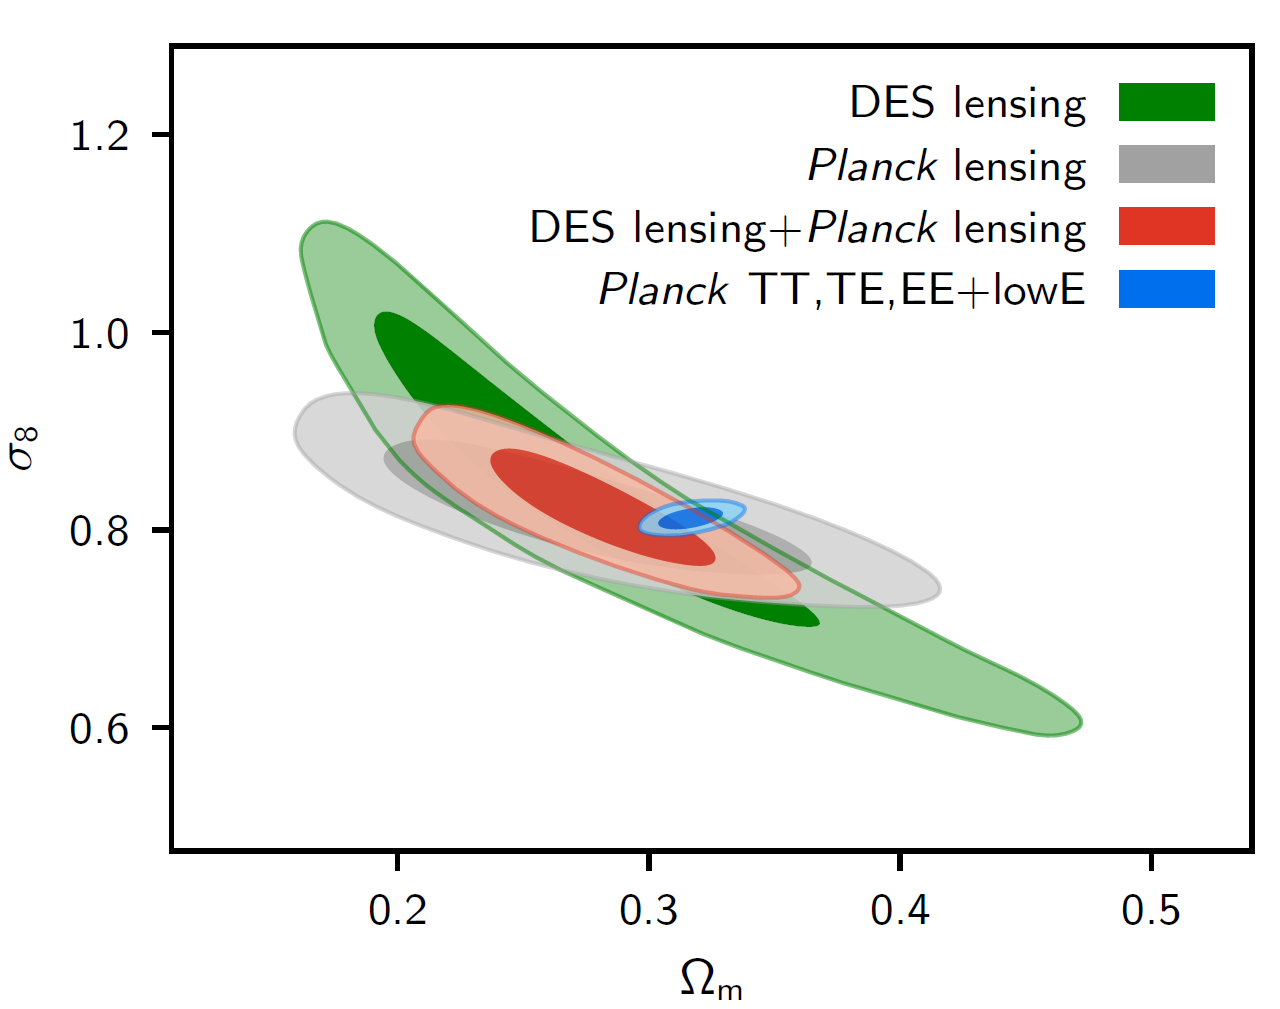

The joint contours above demonstrate how combining Cosmic Microwave Background (CMB) lensing from ESA's **Planck satellite** with cosmic shear and galaxy clustering from the **Dark Energy Survey (DES Y1)** breaks parameter degeneracies between the matter density $\Omega_m$ and fluctuation amplitude $\sigma_8$ ([DES Collaboration, 2018, arXiv:1808.05080](https://arxiv.org/abs/1808.05080)).


<a id="11-model-selection"></a>
## 10. Bayesian Model Selection with MCMC

### 📖 The Odds Ratio & The Bayes Factor
Parameter estimation assumes that the underlying physical model $M$ is correct. However, astrophysicists often face competing hypotheses:
- *Is a spectral line best described by a single Gaussian or a double Gaussian profile?*
- *Is an exoplanet orbit circular ($e = 0$) or eccentric ($e > 0$)?*
- *Is the cosmic expansion accelerating under a cosmological constant ($w = -1$) or dynamic dark energy ($w(a) = w_0 + w_a(1-a)$)?*

According to Bayes' Theorem at the model level:

$$p(M_i | D) = \frac{p(D | M_i) \, p(M_i)}{p(D)}$$

The **Posterior Odds Ratio** $O_{12}$ comparing Model 1 to Model 2 is:

$$O_{12} = \frac{p(M_1 | D)}{p(M_2 | D)} = \underbrace{\frac{p(D | M_1)}{p(D | M_2)}}_{\text{Bayes Factor } B_{12}} \times \underbrace{\frac{p(M_1)}{p(M_2)}}_{\text{Prior Odds}}$$

Where the **Bayes Factor** $B_{12}$ is the ratio of their marginal likelihoods (Evidences):

$$B_{12} = \frac{\mathcal{Z}_1}{\mathcal{Z}_2} = \frac{\int p(D | \boldsymbol{\theta}_1, M_1) \, p(\boldsymbol{\theta}_1 | M_1) \, d\boldsymbol{\theta}_1}{\int p(D | \boldsymbol{\theta}_2, M_2) \, p(\boldsymbol{\theta}_2 | M_2) \, d\boldsymbol{\theta}_2}$$

### The Natural Occam's Razor
Notice that Bayesian model selection naturally penalizes models with unnecessary complexity (excess parameters). If Model 2 introduces unneeded extra parameters, its prior volume $\Omega_2$ expands, diluting the prior density $p(\boldsymbol{\theta}_2 | M_2)$ over a vast volume where the likelihood is near zero. Consequently, its evidence $\mathcal{Z}_2$ drops!

| $|\ln B_{12}|$ | Odds $B_{12}$ | Strength of Evidence (Jeffreys' Scale) |
| :---: | :---: | :--- |
| **$0.0 - 1.0$** | $< 3:1$ | Inconclusive / Barely worth mentioning |
| **$1.0 - 2.5$** | $3:1 - 12:1$ | Substantial evidence |
| **$2.5 - 5.0$** | $12:1 - 150:1$ | Strong evidence |
| **$> 5.0$** | $> 150:1$ | **Decisive evidence** |

---

### Asymptotic Approximations: AIC and BIC
When computing full multi-dimensional evidence integrals is computationally prohibitive, two asymptotic information criteria are widely utilized:

1. **Akaike Information Criterion (AIC)**:
   $$\text{AIC} = 2k - 2 \ln \hat{\mathcal{L}}$$
2. **Bayesian Information Criterion (BIC)**:
   $$\text{BIC} = k \ln N - 2 \ln \hat{\mathcal{L}}$$

Where $k$ is the number of free parameters, $N$ is the sample size, and $\hat{\mathcal{L}}$ is the maximized likelihood. Lower AIC and BIC values indicate preferred models.


In [ ]:
"""
Histogram for Double-gaussian model test
----------------------------------------
Figure 5.23
A sample of 200 points drawn from a Gaussian mixture model used to illustrate
model selection with MCMC.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
try:
    from astroML.density_estimation import GaussianMixture1D
except Exception:
    pass

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Generate the data
mu1_in = 0
sigma1_in = 0.3
mu2_in = 1
sigma2_in = 1
ratio_in = 1.5
N = 200

np.random.seed(10)
gm = GaussianMixture1D([mu1_in, mu2_in],
                       [sigma1_in, sigma2_in],
                       [ratio_in, 1])
x_sample = gm.sample(N)[0]

#------------------------------------------------------------
# Get the MLE fit for a single gaussian
sample_mu = np.mean(x_sample)
sample_std = np.std(x_sample, ddof=1)

#------------------------------------------------------------
# Plot the sampled data
fig, ax = plt.subplots(figsize=(5, 3.75))

ax.hist(x_sample, 20, histtype='stepfilled', density=True, fc='#CCCCCC')
x = np.linspace(-2.1, 4.1, 1000)

factor1 = ratio_in / (1. + ratio_in)
factor2 = 1. / (1. + ratio_in)

ax.plot(x, gm.pdf(x), '-k', label='true distribution')
ax.plot(x, gm.pdf_individual(x), ':k')

ax.plot(x, norm.pdf(x, sample_mu, sample_std), '--k', label='best fit normal')

ax.legend(loc=1)

ax.set_xlim(-2.1, 4.1)

ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$')
ax.set_title('Input pdf and sampled data')
ax.text(0.95, 0.80, ('$\mu_1 = 0;\ \sigma_1=0.3$\n'
                     '$\mu_2=1;\ \sigma_2=1.0$\n'
                     '$\mathrm{ratio}=1.5$'),
        transform=ax.transAxes, ha='right', va='top')
plt.show()

In [ ]:
"""
MCMC Model Comparison
---------------------
Figure 5.24
The top-right panel shows the posterior pdf for mu and sigma for a single
Gaussian fit to the data shown in figure 5.23. The remaining panels show the
projections of the five-dimensional pdf for a Gaussian mixture model with
two components. Contours are based on a 10,000 point MCMC chain.
"""
# Author: Jake VanderPlas (adapted to PyMC3 by Brigitta Sipocz)
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt

from scipy.special import gamma
from sklearn.neighbors import BallTree
import pymc3 as pm
import theano.tensor as tt

try:
    from astroML.density_estimation import GaussianMixture1D
    from astroML.plotting import plot_mcmc
except Exception:
    pass

# ----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def estimate_bayes_factor(trace, r=0.05, return_list=False):
    """Estimate the bayes factor using the local density of points"""

    # Convert traces to a numpy array, ignore the intervals
    trace_arr = np.array([trace[i] for i in trace.varnames if "_interval__" not in i])
    trace_t = trace_arr.T
    N_iter, D = trace_t.shape

    # compute volume of a D-dimensional sphere of radius r
    Vr = np.pi ** (0.5 * D) / gamma(0.5 * D + 1) * (r ** D)

    # use neighbor count within r as a density estimator
    bt = BallTree(trace_t)
    count = bt.query_radius(trace_t, r=r, count_only=True)

    BF = trace.model_logp + np.log(N_iter) + np.log(Vr) - np.log(count)

    if return_list:
        return BF
    else:
        p25, p50, p75 = np.percentile(BF, [25, 50, 75])
        return p50, 0.7413 * (p75 - p25)


# ------------------------------------------------------------
# Generate the data
mu1_in = 0
sigma1_in = 0.3
mu2_in = 1
sigma2_in = 1
ratio_in = 1.5
N = 200

np.random.seed(10)
gm = GaussianMixture1D([mu1_in, mu2_in],
                       [sigma1_in, sigma2_in],
                       [ratio_in, 1])
x_sample = gm.sample(N)[0]


# ------------------------------------------------------------
# Set up pyMC3 model: single gaussian
#  2 parameters: (mu, sigma)
with pm.Model() as model1:
    M1_mu = pm.Uniform('M1_mu', -5, 5)
    M1_log_sigma = pm.Uniform('M1_log_sigma', -10, 10)

    M1 = pm.Normal('M1', mu=M1_mu, sd=np.exp(M1_log_sigma), observed=x_sample)
    trace1 = pm.sample(draws=2500, tune=100)


# ------------------------------------------------------------
# Set up pyMC3 model: mixture of two gaussians
#  5 parameters: (mu1, mu2, sigma1, sigma2, ratio)
with pm.Model() as model2:
    M2_mu1 = pm.Uniform('M2_mu1', -5, 5)
    M2_mu2 = pm.Uniform('M2_mu2', -5, 5)

    M2_log_sigma1 = pm.Uniform('M2_log_sigma1', -10, 10)
    M2_log_sigma2 = pm.Uniform('M2_log_sigma2', -10, 10)

    ratio = pm.Uniform('ratio', 1E-3, 1E3)

    w1 = ratio / (1 + ratio)
    w2 = 1 - w1

    y = pm.NormalMixture('doublegauss',
                         w=tt.stack([w1, w2]),
                         mu=tt.stack([M2_mu1, M2_mu2]),
                         sd=tt.stack([np.exp(M2_log_sigma1),
                                      np.exp(M2_log_sigma2)]),
                         observed=x_sample)

    trace2 = pm.sample(draws=2500, tune=100)


# ------------------------------------------------------------
# Compute Odds ratio with density estimation technique

BF1, dBF1 = estimate_bayes_factor(trace1, r=0.05)
BF2, dBF2 = estimate_bayes_factor(trace2, r=0.05)

# ------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 5))

labels = [r'$\mu_1$',
          r'$\mu_2$',
          r'$\sigma_1$',
          r'$\sigma_2$',
          r'${\rm ratio}$']

true_values = [mu1_in,
               mu2_in,
               sigma1_in,
               sigma2_in,
               ratio_in]

limits = [(-0.18, 0.18),
          (0.5, 1.6),
          (0.12, 0.45),
          (0.76, 1.3),
          (0.3, 2.5)]

# We assume mu1 < mu2, but the results may be switched
# due to the symmetry of the problem.  If so, switch back
if np.median(trace2['M2_mu1']) < np.median(trace2['M2_mu2']):
    trace2_for_plot = [np.exp(trace2[i]) if 'log_sigma' in i else trace2[i] for i in
                       ['M2_mu1', 'M2_mu2', 'M2_log_sigma1', 'M2_log_sigma2', 'ratio']]
else:
    trace2_for_plot = [np.exp(trace2[i]) if 'log_sigma' in i else trace2[i] for i in
                       ['M2_mu2', 'M2_mu1', 'M2_log_sigma2', 'M2_log_sigma1', 'ratio']]

# Plot the simple 2-component model
ax, = plot_mcmc([trace1['M1_mu'], np.exp(trace1['M1_log_sigma'])],
                fig=fig, bounds=[0.6, 0.6, 0.95, 0.95],
                limits=[(0.3, 0.65), (0.75, 1.05)],
                labels=[r'$\mu$', r'$\sigma$'], colors='k')

ax.text(0.05, 0.95, "Single Gaussian fit", va='top', ha='left',
        transform=ax.transAxes)

# Plot the 5-component model
ax_list = plot_mcmc(trace2_for_plot, limits=limits, labels=labels,
                    true_values=true_values, fig=fig,
                    bounds=(0.12, 0.12, 0.95, 0.95),
                    colors='k')
for ax in ax_list:
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_locator(plt.MaxNLocator(4))

plt.show()

It is clear that by all three measures, the double Gaussian model is preferred.
But these measures are only accurate if the posterior distribution is approximately
Gaussian. For non-Gaussian posteriors, the best statistic to use is the odds ratio. While odds ratios involving two-dimensional posteriors can be computed relatively easily, integrating five-dimensional posteriors is computationally
difficult. This is one manifestation of the curse of dimensionality. So how
do we proceed? One way to estimate an odds ratio is based on MCMC sampling.

<a id="12-advanced-samplers"></a>
## 11. Advanced Sampling Paradigms in Modern Astrophysics

While Metropolis-Hastings and `emcee` address a vast spectrum of problems, complex astrophysics presents challenging geometries (multimodal distributions, phase transitions, sharp truncations):

```mermaid
flowchart TD
    A["Sampling Problem in Astrophysics"] --> B{"Gradients Available?"}
    B -- "Yes (Differentiable)" --> C["Hamiltonian Monte Carlo / NUTS<br/>(Stan, PyMC, NumPyro)"]
    B -- "No / Black-Box" --> D{"Primary Objective?"}
    D -- "Parameter Estimation" --> E["Affine-Invariant Ensemble<br/>(emcee)"]
    D -- "Evidence Z / Multimodal" --> F["Nested Sampling<br/>(dynesty, MultiNest, UltraNest)"]
```

### 1. Gibbs Sampling
If the joint distribution is high-dimensional but conditional distributions $p(\theta_i | \boldsymbol{\theta}_{-i}, D)$ for each individual parameter can be sampled directly, **Gibbs sampling** updates each parameter sequentially. 
Because the proposal is the exact conditional distribution, the acceptance probability is **identically 1.0 (no rejected steps!)**.

### 2. Hamiltonian Monte Carlo (HMC) & NUTS
HMC translates sampling into classical Hamiltonian dynamics. The parameter space is treated as a potential energy landscape $V(\boldsymbol{\theta}) = -\ln p(\boldsymbol{\theta})$, and fictitious momentum variables $\boldsymbol{p}$ are introduced. Walkers glide along vector field trajectories computed via numerical leapfrog integrators.
- **Advantage**: Scales gracefully to hundreds or thousands of parameters ($D > 1000$), overcoming random-walk diffusion.
- **Implementations**: [Stan](https://mc-stan.org/), [modern PyMC](https://www.pymc.io/), and JAX-accelerated [NumPyro](https://num.pyro.ai/).

### 3. Nested Sampling (`dynesty`, `MultiNest`)
Invented by [Skilling (2004, 2006)](https://projecteuclid.org/journals/bayesian-analysis/volume-1/issue-4/Nested-sampling-for-general-Bayesian-computation/10.1214/06-BA127.full), **Nested Sampling** transforms the multi-dimensional evidence integral:

$$\mathcal{Z} = \int \mathcal{L}(\boldsymbol{\theta}) \, \pi(\boldsymbol{\theta}) \, d\boldsymbol{\theta} = \int_0^1 \mathcal{L}(X) \, dX$$

into a 1D integral over prior volume $X$.
- **Major Strengths**:
  - Computes the Bayesian Evidence $\mathcal{Z}$ directly with quantifiable statistical uncertainties.
  - Exceptionally robust for complex multimodal posteriors (e.g. gravitational wave chirp parameter matching).
  - Modern Python implementations include [`dynesty`](https://dynesty.readthedocs.io/) and [`UltraNest`](https://johannesbuchner.github.io/UltraNest/).


<a id="13-summary"></a>
## 12. Conceptual Exercises & Master Reference Summary Table

---

### 📌 Summary Reference Table: MCMC Algorithms at a Glance

| Algorithm | Proposal Mechanism | Acceptance Rule | Primary Strength | Known Limitation |
| :--- | :--- | :--- | :--- | :--- |
| **Metropolis (1953)** | Symmetric Gaussian $K(\theta^* \| \theta)$ | $\min(1, p^*/p)$ | Conceptually transparent, trivial to code | Suffers in correlated / high-D spaces |
| **Metropolis-Hastings (1970)** | General asymmetric $K(\theta^* \| \theta)$ | $\min\left(1, \frac{p^* K}{p K^*}\right)$ | Allows targeted/guided proposal jumps | Requires careful proposal density design |
| **Gibbs Sampler** | Exact full conditional $p(\theta_i \| \theta_{-i})$ | $1.0$ (Always accepted) | Zero rejected proposals, no step tuning | Requires analytically tractable conditionals |
| **Affine-Invariant (`emcee`)** | Multi-walker stretch move along vector line | $\min(1, Z^{D-1} p^*/p)$ | **Invariant to linear correlations** | Struggles with strong multimodality |
| **HMC / NUTS** | Hamilton's equations with auxiliary momentum | $\min(1, \exp(-\Delta H))$ | Scales to thousands of dimensions | Requires differentiable log-posterior gradients |
| **Nested Sampling** | Iterative contraction of iso-likelihood prior shell | Direct prior volume scan | **Direct Evidence $\mathcal{Z}$ + handles multimodal peaks** | Computationally expensive in very high-D |

---

### 🧠 Conceptual Exercises for Review

#### Exercise 1: Why does MCMC reject steps?
> **Question**: If our goal is to draw samples from $p(\boldsymbol{\theta})$, why does the Metropolis-Hastings algorithm ever reject proposed steps? What would happen to the distribution of points if every proposed step were accepted?  
> **Solution**: If every proposed step were accepted regardless of probability, the Markov chain would perform an unweighted random walk across the parameter space, asymptotically sampling a uniform distribution proportional only to the proposal kernel. Rejecting candidate points that venture into lower-probability regions (unless accepted with probability $p^* / p$) ensures that the chain spends time in any region of parameter space in exact proportion to the posterior probability density.

#### Exercise 2: The Meaning of Autocorrelation Time
> **Question**: You run an MCMC chain with 32 walkers for 10,000 steps (total 320,000 samples). You compute the integrated autocorrelation time and find $\tau = 250$ steps. How many independent samples have you actually collected?  
> **Solution**: The effective sample size is:
> $$N_{\text{eff}} = \frac{N_{\text{total}}}{\tau} = \frac{320,000}{250} = 1,280 \text{ independent samples}$$
> According to the $50\tau$ rule ($50 \times 250 = 12,500$ steps per walker), the chain should ideally be run for at least 12,500 steps to ensure full convergence.

#### Exercise 3: Symmetry of the Proposal Kernel
> **Question**: Suppose you propose steps in $\theta$ uniformly between $[\theta - a, \theta + b]$ where $a \ne b$. Is this proposal symmetric? Can you use the standard Metropolis acceptance rule?  
> **Solution**: No. Since $a \ne b$, $K(\theta^* | \theta) \ne K(\theta | \theta^*)$. You **cannot** use the symmetric Metropolis ratio; you must use the full Hastings ratio including the factor $K(\theta | \theta^*) / K(\theta^* | \theta)$ to maintain detailed balance and prevent artificial drift toward the larger interval.

---

### 📚 Master Bibliography & Primary Literature
1. **Metropolis, N., et al. (1953)**: *"Equation of State Calculations by Fast Computing Machines"*, J. Chem. Phys., 21, 1087.
2. **Hastings, W. K. (1970)**: *"Monte Carlo Sampling Methods Using Markov Chains and Their Applications"*, Biometrika, 57(1), 97–109.
3. **Gelfand, A. E., & Smith, A. F. (1990)**: *"Sampling-Based Approaches to Calculating Marginal Densities"*, JASA, 85(410), 398–409.
4. **Gelman, A., & Rubin, D. B. (1992)**: [*"Inference from Iterative Simulation Using Multiple Sequences"*](https://projecteuclid.org/journals/statistical-science/volume-7/issue-4/Inference-from-Iterative-Simulation-Using-Multiple-Sequences/10.1214/ss/1177011136.full), Statistical Science, 7(4), 457–472.
5. **Roberts, G. O., Gelman, A., & Gilks, W. R. (1997)**: *"Weak convergence and optimal scaling of random walk Metropolis algorithms"*, Ann. Appl. Probab. 7, 110–120.
6. **Goodman, J., & Weare, J. (2010)**: [*"Ensemble samplers with affine invariance"*](https://msp.org/camcs/2010/5-1/p04.xhtml), CAMCS, 5(1), 65–80.
7. **Hogg, D. W., Bovy, J., & Lang, D. (2010)**: [*"Data analysis recipes: Fitting a model to data"*](https://arxiv.org/abs/1008.4686), arXiv:1008.4686.
8. **Foreman-Mackey, D., et al. (2013)**: [*"emcee: The MCMC Hammer"*](https://arxiv.org/abs/1202.3665), PASP, 125(925), 306.
9. **Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016)**: [*"Probabilistic programming in Python using PyMC3"*](https://peerj.com/articles/cs-55/), PeerJ CS, 2:e55.
10. **Betancourt, M. (2017)**: [*"A Conceptual Introduction to Hamiltonian Monte Carlo"*](https://arxiv.org/abs/1701.02434), arXiv:1701.02434.
11. **DES Collaboration (2018)**: [*"Dark Energy Survey Year 1 Results: Joint Analysis of Galaxy Clustering and Weak Lensing with Planck CMB Lensing"*](https://arxiv.org/abs/1808.05080), arXiv:1808.05080.
12. **Ivezić, Ž., Connolly, A. J., VanderPlas, J. T., & Gray, A. (2014)**: [*Statistics, Data Mining, and Machine Learning in Astronomy*](http://astroML.github.com), Princeton University Press.
